In [2]:
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

##Dataset Loading

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Number of training images: 60000
Number of testing images: 10000


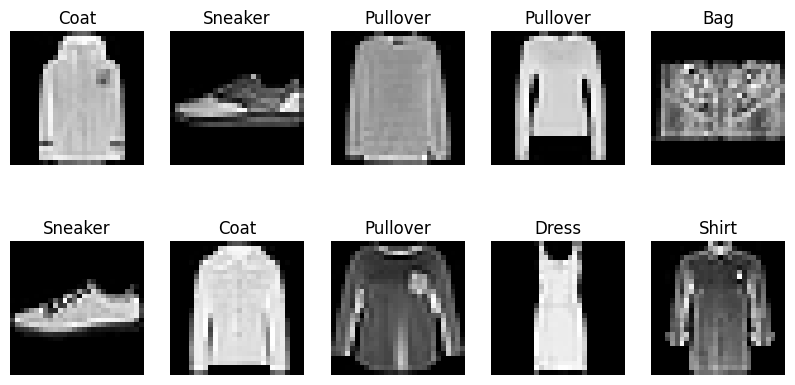

In [3]:
# Load dataset (Fashion-MNIST)
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Print dataset size
print("Number of training images:", X_train.shape[0])
print("Number of testing images:", X_test.shape[0])

# Class labels
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Display 10 random images
plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(X_train))

    plt.subplot(2,5,i+1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.show()

##Data Preprocessing

In [4]:
# Normalize pixel values (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape images for CNN (28,28,1)
X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# One-hot encoding labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Label shape:", y_train.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)
Label shape: (60000, 10)


##Visualization

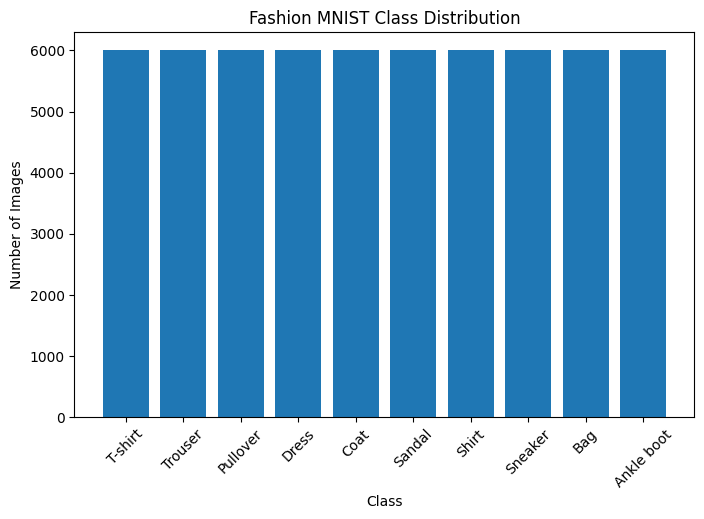

In [5]:
# Count images per class
class_counts = np.bincount(np.argmax(y_train, axis=1))

# Plot bar chart
plt.figure(figsize=(8,5))

plt.bar(range(10), class_counts)
plt.xticks(range(10),
           ['T-shirt','Trouser','Pullover','Dress','Coat',
            'Sandal','Shirt','Sneaker','Bag','Ankle boot'],
           rotation=45)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Fashion MNIST Class Distribution")

plt.show()

##Model Building

In [6]:
# Build CNN model
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# Show model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

##Model Compilation

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

##Model Training

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9757 - loss: 0.0682 - val_accuracy: 0.9773 - val_loss: 0.0637
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9817 - loss: 0.0520 - val_accuracy: 0.9701 - val_loss: 0.0793
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9835 - loss: 0.0488 - val_accuracy: 0.9697 - val_loss: 0.0825
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9864 - loss: 0.0406 - val_accuracy: 0.9658 - val_loss: 0.0907
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9874 - loss: 0.0364 - val_accuracy: 0.9631 - val_loss: 0.1030
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9861 - loss: 0.0365 - val_accuracy: 0.9592 - val_loss: 0.1159
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9913 - loss: 0.0283 - val_accuracy: 0.9612 - val_loss: 0.1139
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9908 - loss: 0.0256 - val_accuracy: 0.

##Model Evaluation

In [14]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9074 - loss: 0.5040
Test Loss: 0.48877206444740295
Test Accuracy: 0.9097999930381775


##Training accuracy vs Validation accuracy

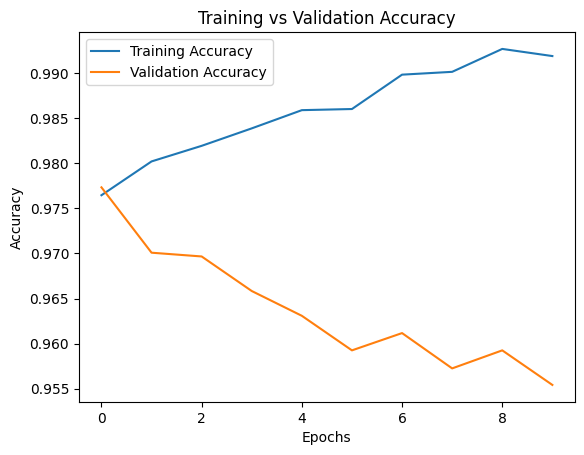

In [12]:
plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(['Training Accuracy','Validation Accuracy'])

plt.show()

##Training loss vs Validation loss

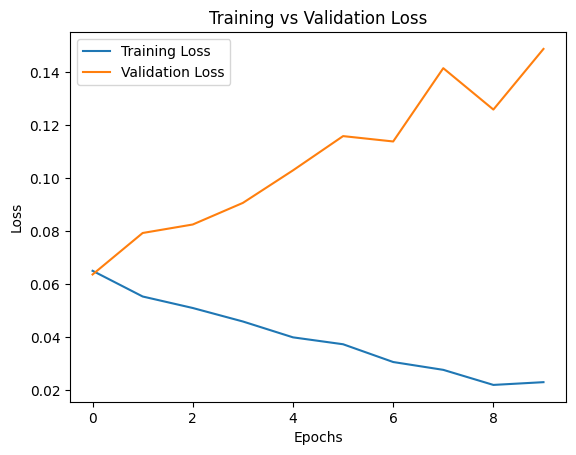

In [13]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss','Validation Loss'])

plt.show()

In [15]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [16]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

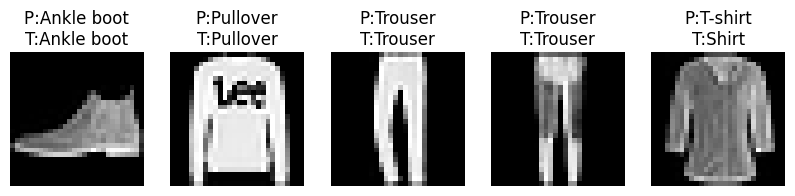

In [17]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    pred = class_names[predicted_labels[i]]
    actual = class_names[true_labels[i]]

    plt.title(f"P:{pred}\nT:{actual}")
    plt.axis('off')

plt.show()

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Convert predictions to class labels
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[841   0  25  16   3   1 109   0   5   0]
 [  1 981   0   8   3   0   5   0   2   0]
 [ 15   1 906   7  34   0  36   0   1   0]
 [ 13   7  21 911  10   0  36   0   1   1]
 [  2   1  82  34 832   0  48   0   1   0]
 [  0   0   0   0   0 983   0  10   1   6]
 [ 90   0  88  17  68   0 734   0   3   0]
 [  0   0   0   0   0  10   0 974   0  16]
 [  2   0   6   5   2   1   4   1 979   0]
 [  1   0   0   0   0   4   0  37   1 957]]


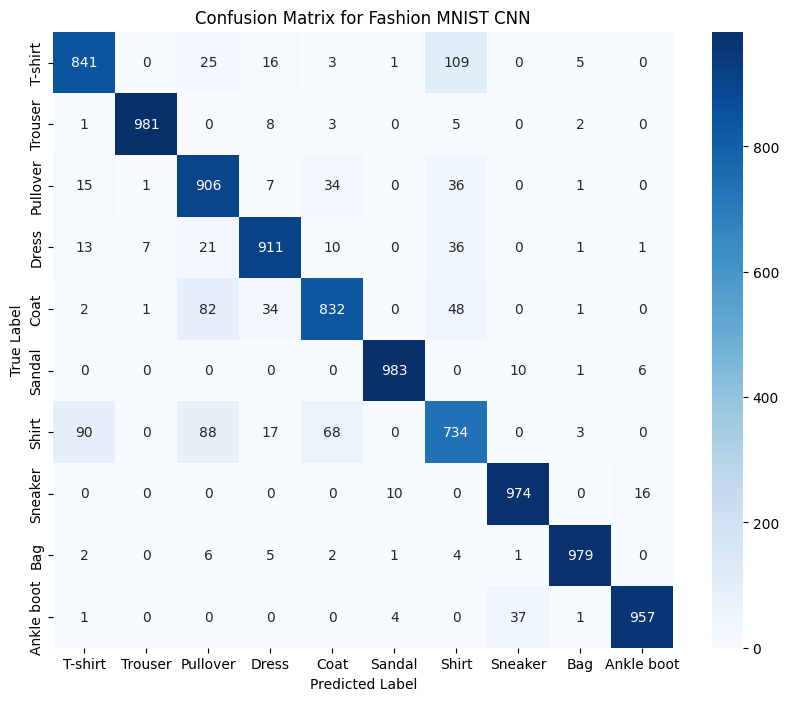

In [19]:
plt.figure(figsize=(10,8))

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Fashion MNIST CNN")

plt.show()

In [20]:
from keras.layers import Dropout

model2 = Sequential()

# First convolution block
model2.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model2.add(Conv2D(32,(3,3),activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Second convolution block
model2.add(Conv2D(64,(3,3),activation='relu'))
model2.add(MaxPooling2D((2,2)))

# Dropout layer to prevent overfitting
model2.add(Dropout(0.25))

# Flatten
model2.add(Flatten())

# Dense layer
model2.add(Dense(128,activation='relu'))

# Output layer
model2.add(Dense(10,activation='softmax'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,282 (915.16 KB)

 Trainable params: 234,282 (915.16 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history2 = model2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7356 - loss: 0.7237 - val_accuracy: 0.8708 - val_loss: 0.3595
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8729 - loss: 0.3437 - val_accuracy: 0.8882 - val_loss: 0.3056
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8995 - loss: 0.2797 - val_accuracy: 0.9107 - val_loss: 0.2493
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9094 - loss: 0.2496 - val_accuracy: 0.9172 - val_loss: 0.2390
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9182 - loss: 0.2216 - val_accuracy: 0.9137 - val_loss: 0.2370
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9265 - loss: 0.1971 - val_accuracy: 0.9149 - val_loss: 0.2350
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9323 - loss: 0.1844 - val_accuracy: 0.9215 - val_loss: 0.2185
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9387 - loss: 0.1653 - val_accuracy: 0.

In [23]:
loss2, acc2 = model2.evaluate(X_test, y_test)

print("Improved Model Test Accuracy:", acc2)
print("Improved Model Test Loss:", loss2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9217 - loss: 0.2340
Improved Model Test Accuracy: 0.9211999773979187
Improved Model Test Loss: 0.23143386840820312


In [24]:
loss1, acc1 = model.evaluate(X_test, y_test)

print("Model 1 Accuracy:", acc1)
print("Model 2 Accuracy:", acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9074 - loss: 0.5040
Model 1 Accuracy: 0.9097999930381775
Model 2 Accuracy: 0.9211999773979187


In [25]:
# Get predictions
predictions = model2.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Find indices where prediction is wrong
wrong_indices = np.where(predicted_labels != true_labels)[0]

print("Total Misclassified Images:", len(wrong_indices))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Total Misclassified Images: 788


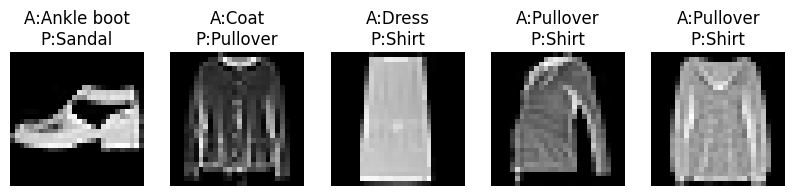

In [26]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,5))

for i in range(5):

    index = wrong_indices[i]

    plt.subplot(1,5,i+1)
    plt.imshow(X_test[index].reshape(28,28), cmap='gray')

    actual = class_names[true_labels[index]]
    predicted = class_names[predicted_labels[index]]

    plt.title(f"A:{actual}\nP:{predicted}")
    plt.axis('off')

plt.show()

In [28]:
from keras.models import Model

# Select first convolution layer output
layer_outputs = [layer.output for layer in model2.layers if 'conv' in layer.name]

# Create new model that outputs feature maps
# Fix: Use model2.layers[0].input to explicitly get the input tensor from the first layer
feature_map_model = Model(inputs=model2.layers[0].input, outputs=layer_outputs)

In [29]:
# Select one image from test set
sample_image = X_test[0].reshape(1,28,28,1)

In [30]:
feature_maps = feature_map_model.predict(sample_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step


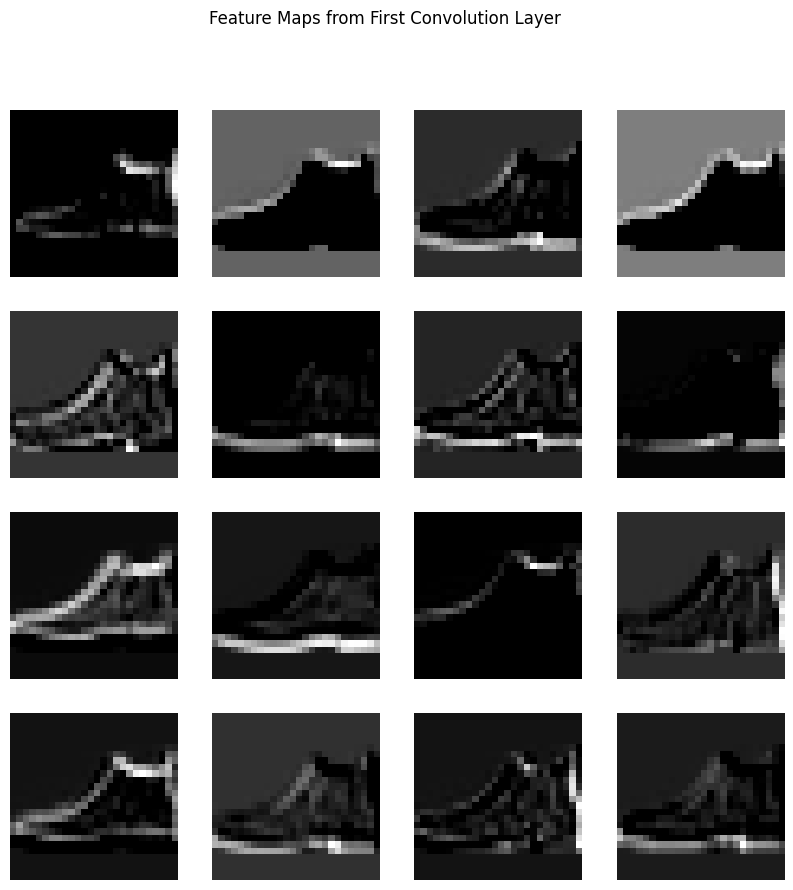

In [31]:
feature_map = feature_maps[0]

plt.figure(figsize=(10,10))

for i in range(16):  # show first 16 filters
    plt.subplot(4,4,i+1)
    plt.imshow(feature_map[0,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

In [32]:
index = np.random.randint(0, len(X_test))

test_image = X_test[index]
true_label = np.argmax(y_test[index])

In [33]:
prediction = model2.predict(test_image.reshape(1,28,28,1))

predicted_class = np.argmax(prediction)
probability = np.max(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step


Actual Label: Sneaker
Predicted Label: Sneaker
Prediction Confidence: 1.0


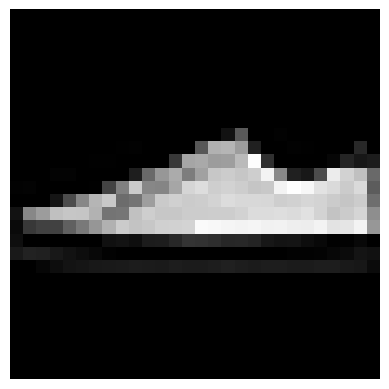

In [34]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.imshow(test_image.reshape(28,28), cmap='gray')
plt.axis('off')

print("Actual Label:", class_names[true_label])
print("Predicted Label:", class_names[predicted_class])
print("Prediction Confidence:", probability)